# 3. Computer Vision
following topics are provided by the syllabus:
1. [x] Convolutional Layers
2. [x] Image Classification
3. [x] Object Detection (YOLO, SSD, DERT)
4. [x] Image Segmentation (U-Net)
5. [x] Pre-trained Vision Encoders (e.g. ResNet)
6. [x] Image Augmentation
7. [x] Generating Images with GANs
8. [x] Self-Supervised Learning for Vision
9. [x] Vision-text encoders (e.g. CLIP)
10. [x] Diffusion Models

It becomes clear what Computer Vision entails by looking at the topics above. It is a field of study that focuses on enabling computers to interpret and understand visual information from the world, such as images and videos. The main component of computer vision is the use of convolutional layers. They have 2 very important properties: pattern recognition and local independence. Pattern recognition allows the model to identify and learn patterns in the input data, while local independence allows the model to recognize them regardless of their position in the input.

## Image classification
We start by creating a simple image classification model using a convolutional neural network (CNN). The model will be trained on a dataset of cats and dogs. The goal is to classify the images into different categories based on their content. We aim to cover topics 1, 2, 5, and 6 from the syllabus, as well as Autoencoders, Data Embeddigns, Pooling Techniques and Weight Initialization from the previous Chapter. The model will consist of several convolutional layers followed by fully connected layers. We will also apply image augmentation techniques to improve the model's performance and generalization ability.

### Data loading

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import os
from PIL import Image

data_transforms = transforms.Compose([

    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

# no Normalize here: the autoencoder ends in a Sigmoid, so inputs/targets must be in [0, 1]
autoencoder_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

class PetImagesAutoencoderDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        super().__init__()
        self.transform = transform
        self.image_paths = []
        for label in ['Cat', 'Dog']:
            label_dir = os.path.join(root_dir, label)
            for img_name in os.listdir(label_dir):
                if img_name.lower().endswith('.jpg'):
                    self.image_paths.append(os.path.join(label_dir, img_name))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.image_paths[idx]).convert('RGB')
        except Exception:  # PetImages contains a few corrupt files
            return self.__getitem__((idx + 1) % len(self))
        if self.transform is not None:
            image = self.transform(image)
        return image, image # return the same image as both input and target

dataset = torchvision.datasets.ImageFolder(root='./PetImages', transform=data_transforms)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)
autoencoder_dataset = PetImagesAutoencoderDataset(root_dir='./PetImages', transform=autoencoder_transforms)
# num_workers=0: classes defined in a notebook can't be pickled for spawn-based workers on Windows
dataloader_autoencoder = torch.utils.data.DataLoader(autoencoder_dataset, batch_size=32, shuffle=True, num_workers=0)

### Caching the dataset in memory
Decoding 25k JPEGs every epoch is by far the slowest part of training, and we only need 32x32 pixels. So we decode and resize everything **once**, keep it as one `(N, 3, 32, 32)` tensor on the GPU and reuse it for every section below. `GPULoader` is a tiny replacement for `DataLoader` that slices this tensor directly. We also hold out 5000 images as a test set that no model is ever trained on.

In [20]:
import random
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225] # ImageNet statistics

cache_path = 'pets32.pt'
if os.path.exists(cache_path):
    cache = torch.load(cache_path)
else:
    to_uint8 = transforms.Compose([transforms.Resize((32, 32)), transforms.PILToTensor()])
    cache_ds = PetImagesAutoencoderDataset(root_dir='./PetImages', transform=to_uint8)
    cache = {
        'images': torch.stack([cache_ds[i][0] for i in range(len(cache_ds))]), # (N, 3, 32, 32) uint8
        'labels': torch.tensor([0 if os.path.basename(os.path.dirname(p)) == 'Cat' else 1 for p in cache_ds.image_paths]),
    }
    torch.save(cache, cache_path)

pets = cache['images'].float().div(255).to(device) # (N, 3, 32, 32) in [0, 1]
pet_labels = cache['labels'].to(device)            # 0 = cat, 1 = dog

perm = torch.randperm(len(pets), generator=torch.Generator().manual_seed(0)).to(device)
test_idx, train_idx = perm[:5000], perm[5000:]
x_tr, y_tr = pets[train_idx], pet_labels[train_idx]
x_te, y_te = pets[test_idx], pet_labels[test_idx]
print(pets.shape, x_tr.shape, x_te.shape)


class GPULoader:
    """Minimal DataLoader for tensors that already live on the GPU. Yields (x, y), or just x if y is None."""
    def __init__(self, x, y=None, batch_size=128, shuffle=True):
        self.x, self.y, self.batch_size, self.shuffle = x, y, batch_size, shuffle

    def __len__(self):
        return (len(self.x) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        idx = torch.randperm(len(self.x), device=self.x.device) if self.shuffle else torch.arange(len(self.x), device=self.x.device)
        for i in range(0, len(idx), self.batch_size):
            j = idx[i:i + self.batch_size]
            yield (self.x[j], self.y[j]) if self.y is not None else self.x[j]


# the autoencoder trains on the cached tensors too (input and target are the same image)
dataloader_autoencoder = GPULoader(x_tr, x_tr, batch_size=64)


def show_images(x, nrow=8, title=None, size=10):
    grid = make_grid(x.detach().cpu().clamp(0, 1), nrow=nrow, padding=1)
    plt.figure(figsize=(size, size * grid.shape[1] / grid.shape[2]))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def random_images(n, seed=0):
    """n random full-resolution (PIL image, label, path) triples, skipping the few corrupt files"""
    rng, out = random.Random(seed), []
    while len(out) < n:
        path = rng.choice(autoencoder_dataset.image_paths)
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            continue
        out.append((img, 0 if os.path.basename(os.path.dirname(path)) == 'Cat' else 1, path))
    return out

torch.Size([24998, 3, 32, 32]) torch.Size([19998, 3, 32, 32]) torch.Size([5000, 3, 32, 32])


### Convolutional layers
A convolutional layer slides a small kernel (e.g. 3x3) over the image and computes a weighted sum at every position. The same weights are reused everywhere, which gives us
- **few parameters**: they depend on the kernel size and the number of channels, not on the image size (a fully connected layer would need one weight per input-output pixel pair)
- **translation equivariance**: a pattern is detected no matter where it appears (this is the "local independence" from above)
- **hierarchy**: early layers detect edges, later layers combine them into textures, parts and objects, since each layer sees a larger receptive field than the last

The output size of a layer is `floor((n + 2*padding - kernel) / stride) + 1`. **Pooling** shrinks the feature map further: max pooling keeps the strongest activation of every window, average pooling keeps the mean. Below, hand-crafted kernels (blur and Sobel edge detectors) show what a kernel does. A CNN simply *learns* its kernels by gradient descent instead of us picking them.

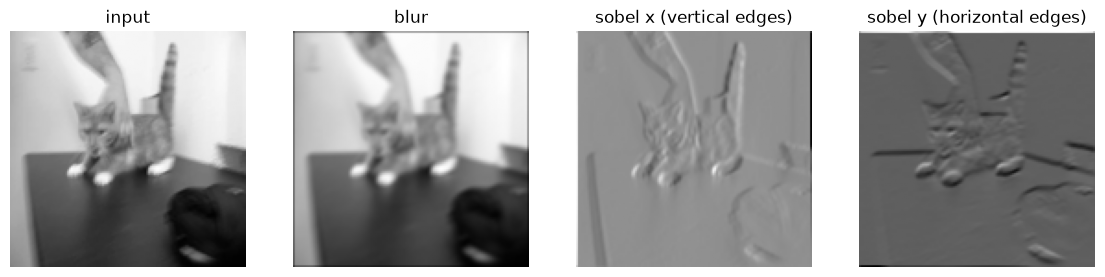

conv parameters:   448
linear parameters for the same 3x32x32 -> 16x16x16 mapping: 12587008
conv output: (1, 16, 16, 16) = floor((32 + 2*1 - 3) / 2) + 1 = 16
after max pool: (1, 16, 8, 8) | after avg pool: (1, 16, 8, 8)


In [21]:
img = Image.open(autoencoder_dataset.image_paths[0]).convert('L').resize((128, 128))
x = torch.tensor(np.array(img), dtype=torch.float32)[None, None] / 255 # (1, 1, 128, 128)

kernels = {
    'blur': torch.ones(3, 3) / 9,
    'sobel x (vertical edges)': torch.tensor([[-1., 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'sobel y (horizontal edges)': torch.tensor([[-1., -2, -1], [0, 0, 0], [1, 2, 1]]),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(x[0, 0], cmap='gray')
axes[0].set_title('input')
for ax, (name, k) in zip(axes[1:], kernels.items()):
    out = F.conv2d(x, k[None, None], padding=1) # one 3x3 kernel slid over the whole image
    ax.imshow(out[0, 0], cmap='gray')
    ax.set_title(name)
for ax in axes:
    ax.axis('off')
plt.show()

conv = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
print('conv parameters:  ', sum(p.numel() for p in conv.parameters()))
print('linear parameters for the same 3x32x32 -> 16x16x16 mapping:', (3 * 32 * 32) * (16 * 16 * 16) + 16 * 16 * 16)

feat = conv(torch.randn(1, 3, 32, 32))
print('conv output:', tuple(feat.shape), '= floor((32 + 2*1 - 3) / 2) + 1 =', (32 + 2 - 3) // 2 + 1)
print('after max pool:', tuple(nn.MaxPool2d(2)(feat).shape), '| after avg pool:', tuple(nn.AvgPool2d(2)(feat).shape))

### Convolutional Neural Network (CNN) Model

In [22]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5) # 3 input channels (RGB), 6 output channels, 5x5 kernel
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # 16 channels, 5x5 feature map size
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2) # 2 output classes (cat and dog)
        self.relu = nn.modules.activation.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5) # squeeze 16 channels and 5 by 5 "image" into a single vector
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Training the Model

In [23]:
def train(model, num_epochs=10, dataloader=dataloader, augment=None, lr=0.001):
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

    print(device)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=lr) # skips frozen parameters

    model.train()
    for _ in range(num_epochs):
        running_loss = 0.0
        for i, data in enumerate(dataloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            if augment is not None:
                inputs = augment(inputs)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {_ + 1}, Loss: {running_loss / len(dataloader):.4f}')

    return model # the model is already trained, but we return it for further use if needed


@torch.no_grad()
def evaluate(model, x, y, batch_size=512):
    model.eval()
    correct = sum((model(xb).argmax(1) == yb).sum().item() for xb, yb in GPULoader(x, y, batch_size, shuffle=False))
    return correct / len(x)

#### Training and evaluating the CNN
We train on the cached tensors and measure accuracy on the 5000 held-out images. The ImageNet normalization is part of the model (`transforms.Normalize` also works on whole batches), so the data can stay in `[0, 1]`. A tiny CNN on 32x32 pixels is not going to be great, since cats and dogs are hard to separate at this resolution. The later sections show how augmentation and pre-trained encoders improve on this baseline.

In [24]:
train_loader = GPULoader(x_tr, y_tr, batch_size=128)

cnn = nn.Sequential(transforms.Normalize(MEAN, STD), Net())
train(cnn, 15, train_loader)
print(f'CNN test accuracy: {evaluate(cnn, x_te, y_te):.3f}')

cuda
Epoch 1, Loss: 0.6363
Epoch 2, Loss: 0.5773
Epoch 3, Loss: 0.5384
Epoch 4, Loss: 0.5141
Epoch 5, Loss: 0.4863
Epoch 6, Loss: 0.4694
Epoch 7, Loss: 0.4401
Epoch 8, Loss: 0.4174
Epoch 9, Loss: 0.3923
Epoch 10, Loss: 0.3654
Epoch 11, Loss: 0.3465
Epoch 12, Loss: 0.3152
Epoch 13, Loss: 0.2816
Epoch 14, Loss: 0.2525
Epoch 15, Loss: 0.2292
CNN test accuracy: 0.724


### Autoencoders
Autoencoders are a type of neural network used for unsupervised learning. They consist of an encoder and a decoder. The encoder compresses the input data into a lower-dimensional latent space, while the decoder reconstructs the original data from this representation. The network tries to minimize the difference between the input and the reconstructed output. Autoencoders can be used for tasks such as dimensionality reduction, denoising, and anomaly detection. In this notebook, we will implement a simple autoencoder for image calssification

In [25]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super(Autoencoder, self).__init__()
        def down(i, o): # halves the spatial size
            return [nn.Conv2d(i, o, 3, stride=2, padding=1), nn.BatchNorm2d(o), nn.ReLU()]
        def up(i, o): # doubles the spatial size
            return [nn.ConvTranspose2d(i, o, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(o), nn.ReLU()]

        self.encoder = nn.Sequential(
            *down(3, 32),    # 3x32x32 -> 32x16x16
            *down(32, 64),   # -> 64x8x8
            *down(64, 128),  # -> 128x4x4
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, latent_dim) # latent vector, one row per image
        )
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            *up(128, 64),    # 128x4x4 -> 64x8x8
            *up(64, 32),     # -> 32x16x16
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1), # -> 3x32x32
            nn.Sigmoid() # to ensure the output is in the range [0,1]
        )

    def encode(self, x):
        return self.encoder(x) # (batch, latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(self.fc(z).view(-1, 128, 4, 4))

### Training the Autoencoder

In [26]:
def train_autoencoder(model, num_epochs=10, dataloader=dataloader_autoencoder, lr=1e-3):
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    print(device)
    model.to(device)

    criterion = nn.MSELoss() # reconstruction loss between output and input
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            reconstructed = model(inputs)
            loss = criterion(reconstructed, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(dataloader):.4f}')

    return model

autoencoder = train_autoencoder(Autoencoder(), 10)
torch.save(autoencoder.state_dict(), 'autoencoder.pth')

cuda
Epoch 1, Loss: 0.0199
Epoch 2, Loss: 0.0113
Epoch 3, Loss: 0.0093
Epoch 4, Loss: 0.0082
Epoch 5, Loss: 0.0080
Epoch 6, Loss: 0.0079
Epoch 7, Loss: 0.0078
Epoch 8, Loss: 0.0077
Epoch 9, Loss: 0.0077
Epoch 10, Loss: 0.0076


In [27]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
autoencoder = Autoencoder()
autoencoder.load_state_dict(torch.load('autoencoder.pth', map_location=device))
autoencoder.to(device).eval()

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=2048, out_features=64, bias=True)
  )
  (fc): Linear(in_features=64, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv

In [28]:
import numpy as np

# encode a random subset (decoding every JPEG would take a while)
rng = np.random.default_rng(0)
subset = rng.choice(len(autoencoder_dataset), size=3000, replace=False)

images = torch.stack([autoencoder_dataset[int(i)][0] for i in subset])
labels = np.array([0 if os.path.basename(os.path.dirname(autoencoder_dataset.image_paths[i])) == 'Cat' else 1 for i in subset])

with torch.no_grad():
    latents = autoencoder.encode(images.to(device)).cpu().numpy() # (3000, 64)
print(latents.shape)

(3000, 64)


C:\Users\pstay\code\competitions\IOAI\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


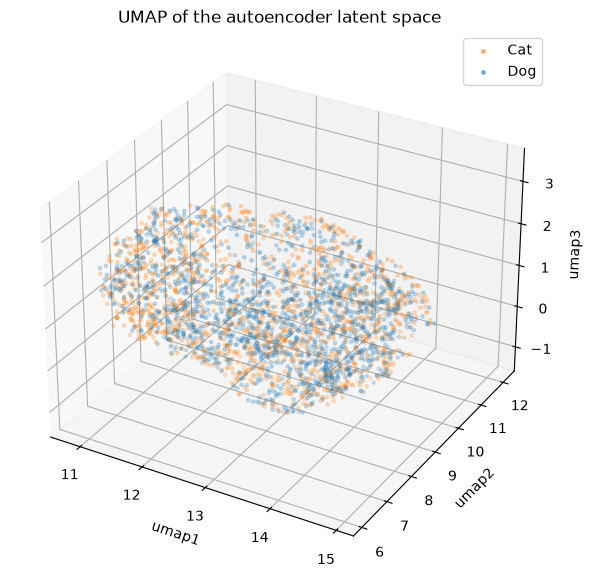

In [29]:
import matplotlib.pyplot as plt
import umap

# UMAP squeezes the 64D latents down to 3D purely for visualisation
latents_3d = umap.UMAP(n_components=3, random_state=0).fit_transform(latents)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection='3d')
for label, name, color in [(0, 'Cat', 'tab:orange'), (1, 'Dog', 'tab:blue')]:
    pts = latents_3d[labels == label]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=6, alpha=0.5, c=color, label=name)
ax.set_xlabel('umap1'); ax.set_ylabel('umap2'); ax.set_zlabel('umap3')
ax.set_title('UMAP of the autoencoder latent space')
ax.legend()
plt.show()

KNN accuracy on the latents: 0.592


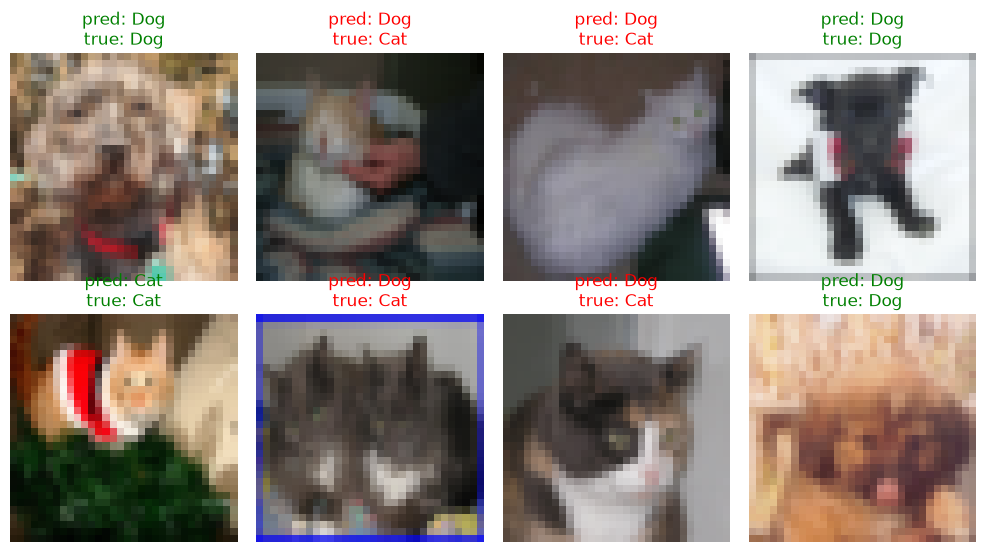

In [30]:
import random
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# KNN runs on the full 64D latents, not the UMAP projection
Z_train, Z_test, X_train, X_test, y_train, y_test = train_test_split(
    latents, images, labels, test_size=0.2, random_state=0, stratify=labels
)

knn = KNeighborsClassifier(n_neighbors=5).fit(Z_train, y_train)
preds = knn.predict(Z_test)
print(f'KNN accuracy on the latents: {(preds == y_test).mean():.3f}')

# show sample predictions only
class_names = ['Cat', 'Dog']
sample = random.sample(range(len(Z_test)), 8)
fig, axes = plt.subplots(2, 4, figsize=(10, 5.5))
for ax, i in zip(axes.flat, sample):
    ax.imshow(X_test[i].permute(1, 2, 0).numpy())
    correct = preds[i] == y_test[i]
    ax.set_title(f'pred: {class_names[preds[i]]}\ntrue: {class_names[y_test[i]]}', color='green' if correct else 'red')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Image augmentation
Augmentation creates new training examples by applying random label-preserving transformations (flips, crops, rotations, color changes, noise, cutout, ...). The model never sees the exact same image twice, which acts as a strong regularizer and is often the cheapest way to improve a vision model. Rules of thumb:
- only augment the **training** set, never validation or test data
- the transformation must keep the label valid (a flipped cat is still a cat, but a flipped "6" is not a "6")
- there are also augmentations that mix samples: **mixup** blends two images and their labels, **CutMix** pastes a patch of one image into another

`torchvision.transforms.v2` works on PIL images and tensors. Here is what a pipeline does to one photo:

In [ ]:
from torchvision.transforms import v2

aug_pipeline = v2.Compose([
    v2.RandomResizedCrop(128, scale=(0.5, 1.0)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
])

photo = random_images(1)[0][0]
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes[0, 0].imshow(photo.resize((128, 128)))
axes[0, 0].set_title('original')
for ax in axes.flat[1:]:
    ax.imshow(aug_pipeline(photo))
for ax in axes.flat:
    ax.axis('off')
plt.show()

Running PIL transforms on the CPU for every image is slow. Since our data already lives on the GPU as one tensor, we write the same idea as one vectorized function: `affine_grid` + `grid_sample` give every image its own random zoom/crop and flip, and we jitter brightness and contrast per image. We use it below and again for self-supervised learning.

In [ ]:
def gpu_augment(x, min_scale=0.6, color=0.2):
    B, dev = x.shape[0], x.device
    s = torch.empty(B, device=dev).uniform_(min_scale, 1.0)   # fraction of the image that is kept (zoom)
    tx = (torch.rand(B, device=dev) * 2 - 1) * (1 - s)        # random crop position
    ty = (torch.rand(B, device=dev) * 2 - 1) * (1 - s)
    flip = (torch.rand(B, device=dev) < 0.5).float() * 2 - 1  # random horizontal flip
    theta = torch.zeros(B, 2, 3, device=dev)
    theta[:, 0, 0], theta[:, 0, 2] = s * flip, tx
    theta[:, 1, 1], theta[:, 1, 2] = s, ty
    x = F.grid_sample(x, F.affine_grid(theta, x.shape, align_corners=False), padding_mode='reflection', align_corners=False)

    brightness = torch.empty(B, 1, 1, 1, device=dev).uniform_(1 - color, 1 + color)
    contrast = torch.empty(B, 1, 1, 1, device=dev).uniform_(1 - color, 1 + color)
    mean = x.mean(dim=(1, 2, 3), keepdim=True)
    return (((x - mean) * contrast + mean) * brightness).clamp(0, 1)


show_images(torch.cat([x_te[:8], gpu_augment(x_te[:8]), gpu_augment(x_te[:8])]), title='original (top) and two augmented versions')

Now we train the same CNN with and without augmentation for 40 epochs each and compare. Without augmentation the training loss keeps falling while the test accuracy stalls (the model memorizes the training set). With augmentation the training loss stays higher (the task is harder) but the test accuracy is better, because the model overfits less. Augmentation needs more epochs to pay off, since every epoch shows slightly different images.

In [ ]:
plain_cnn = nn.Sequential(transforms.Normalize(MEAN, STD), Net())
train(plain_cnn, 40, train_loader)

aug_cnn = nn.Sequential(transforms.Normalize(MEAN, STD), Net())
train(aug_cnn, 40, train_loader, augment=gpu_augment)

print(f'without augmentation: {evaluate(plain_cnn, x_te, y_te):.3f}')
print(f'with augmentation:    {evaluate(aug_cnn, x_te, y_te):.3f}')

Epoch 25, Loss: 0.0544
Epoch 26, Loss: 0.0682
Epoch 27, Loss: 0.0429
Epoch 28, Loss: 0.0460
Epoch 29, Loss: 0.0308
Epoch 30, Loss: 0.0548
Epoch 31, Loss: 0.0340
Epoch 32, Loss: 0.0276
Epoch 33, Loss: 0.0729
Epoch 34, Loss: 0.0351
Epoch 35, Loss: 0.0255
Epoch 36, Loss: 0.0220
Epoch 37, Loss: 0.0249
Epoch 38, Loss: 0.0422
Epoch 39, Loss: 0.0426
Epoch 40, Loss: 0.0374
cuda
Epoch 1, Loss: 0.6702
Epoch 2, Loss: 0.6338
Epoch 3, Loss: 0.6156
Epoch 4, Loss: 0.5907
Epoch 5, Loss: 0.5811
Epoch 6, Loss: 0.5703
Epoch 7, Loss: 0.5607
Epoch 8, Loss: 0.5558
Epoch 9, Loss: 0.5434
Epoch 10, Loss: 0.5428


## Pre-trained vision encoders (ResNet)
Training a good encoder from scratch needs millions of images. Instead we start from a network trained on ImageNet (1.2M images, 1000 classes). Its early layers already detect edges and textures and its last layers produce a rich embedding of the image, so it transfers well to almost any vision task. ResNet's key idea is the **residual connection** `y = x + f(x)`, which lets gradients flow through very deep networks.

There are three ways to reuse a pre-trained model, from cheapest to most expensive:
1. **Feature extraction**: freeze the backbone, use the embedding as input to a classic model (logistic regression, k-NN, ...)
2. **Linear probe / partial finetuning**: freeze the backbone and train only a new classification head. This is the simplest *parameter-efficient* finetuning, other methods are adapters and LoRA, which train small extra layers only
3. **Full finetuning**: train everything with a small learning rate, since the pre-trained weights only need a nudge

Pre-trained models expect the input preprocessing they were trained with: ImageNet mean/std and a reasonable resolution. Our images are only 32x32, so we upsample them to 64x64 inside the model.

In [ ]:
import torchvision.models as models

def make_resnet(freeze_backbone):
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in resnet.parameters():
            p.requires_grad = False
    resnet.fc = nn.Linear(resnet.fc.in_features, 2) # new head, created after freezing so it stays trainable
    return nn.Sequential(nn.Upsample(size=64, mode='bilinear'), transforms.Normalize(MEAN, STD), resnet)

frozen = make_resnet(freeze_backbone=True)
train(frozen, 3, train_loader, augment=gpu_augment, lr=1e-3)
print(f'frozen backbone, only the head trained: {evaluate(frozen, x_te, y_te):.3f}')

full = make_resnet(freeze_backbone=False)
train(full, 3, train_loader, augment=gpu_augment, lr=1e-4) # smaller lr for the pre-trained weights
print(f'full finetuning:                        {evaluate(full, x_te, y_te):.3f}')

The backbone can also be used as a plain **embedding model** and combined with the classical algorithms from the first notebook. Every image becomes a 512 dimensional vector and a logistic regression on top of it works surprisingly well.

In [ ]:
from sklearn.linear_model import LogisticRegression

# frozen ResNet without its last layer: image -> 512 dimensional embedding
feature_extractor = nn.Sequential(frozen[0], frozen[1], *list(frozen[2].children())[:-1], nn.Flatten()).eval()

@torch.no_grad()
def extract(x):
    return torch.cat([feature_extractor(xb) for xb in GPULoader(x, batch_size=512, shuffle=False)]).cpu().numpy()

f_tr, f_te = extract(x_tr), extract(x_te)
logreg = LogisticRegression(max_iter=2000).fit(f_tr, y_tr.cpu().numpy())
print(f'embeddings {f_tr.shape} + logistic regression: {logreg.score(f_te, y_te.cpu().numpy()):.3f}')

## Self-supervised learning for vision
Labels are expensive, images are not. Self-supervised learning invents a task that needs no labels so the network still learns useful features, which we then reuse for the real task with only a few labels. The autoencoder above is already one example (reconstruct the input). The most popular family is **contrastive learning** (SimCLR, MoCo): take an image, create two random augmented views of it, and train the encoder so that the two views of the same image get similar embeddings while views of *different* images get pushed apart. The loss (NT-Xent) is a cross entropy over the similarity matrix where the positive pair is the "correct class".

Other approaches: masked image modeling (MAE hides patches and reconstructs them), self-distillation (BYOL, DINO) and predicting rotations. The recipe is always the same: pretrain without labels, then train a linear classifier (or finetune) on the frozen features. We pretrain on all training images **without using their labels** and then only use 2000 labels for the linear classifier.

In [ ]:
def conv_bn(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU())

def make_encoder():
    return nn.Sequential(conv_bn(3, 64), nn.MaxPool2d(2), conv_bn(64, 128), nn.MaxPool2d(2), conv_bn(128, 256),
                         nn.AdaptiveAvgPool2d(1), nn.Flatten()) # image -> 256 dimensional embedding

class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = make_encoder()
        self.projector = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 64)) # the loss is applied here, we keep the encoder

    def forward(self, x):
        return self.projector(self.encoder(x))

def nt_xent(z1, z2, temperature=0.2):
    B = z1.shape[0]
    z = F.normalize(torch.cat([z1, z2]), dim=1)
    sim = z @ z.T / temperature                                            # (2B, 2B) cosine similarities
    sim.fill_diagonal_(float('-inf'))                                      # an image is not its own positive
    positives = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)  # view i <-> view i + B
    return F.cross_entropy(sim, positives)

simclr = SimCLR().to(device)
optimizer = optim.AdamW(simclr.parameters(), lr=1e-3)
ssl_loader = GPULoader(x_tr, batch_size=256) # no labels

for epoch in range(60):
    simclr.train()
    total = 0.0
    for xb in ssl_loader:
        v1, v2 = gpu_augment(xb, min_scale=0.4, color=0.4), gpu_augment(xb, min_scale=0.4, color=0.4) # two strong views
        loss = nt_xent(simclr(v1), simclr(v2))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    print(f'Epoch {epoch + 1}, Loss: {total / len(ssl_loader):.4f}')

To check whether the features are any good we train a logistic regression on the frozen embeddings using only 2000 labeled images, and compare against an encoder with random weights. The pretrained encoder should be clearly better (about 0.73 vs 0.67 in our runs), which means it learned something about the images without ever seeing a label. Note that a random conv net is already a decent feature extractor, so the gap is modest on such a small dataset.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

@torch.no_grad()
def embed(encoder, x):
    encoder.eval()
    return torch.cat([encoder(xb) for xb in GPULoader(x, batch_size=512, shuffle=False)]).cpu().numpy()

def linear_probe(encoder, n_labels=2000):
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    probe.fit(embed(encoder, x_tr[:n_labels]), y_tr[:n_labels].cpu().numpy())
    return probe.score(embed(encoder, x_te), y_te.cpu().numpy())

print(f'random encoder + linear probe:      {linear_probe(make_encoder().to(device)):.3f}')
print(f'SimCLR encoder + linear probe:      {linear_probe(simclr.encoder):.3f}')

## Vision-text encoders (CLIP)
CLIP trains **two encoders at once**, an image encoder and a text encoder, on 400M (image, caption) pairs from the internet. Both map into the same embedding space and the loss is contrastive, just like SimCLR, but the positive pair is now an image and *its caption*. In a batch of `B` pairs the `B x B` similarity matrix should have its maximum on the diagonal, and the loss is a cross entropy over the rows (image -> text) and over the columns (text -> image).

Because images and text share one space, CLIP can do **zero-shot classification** without any training on our data: write one sentence per class ("a photo of a cat"), embed them, and predict the class whose text embedding is closest to the image embedding. The same embeddings power image search and are used to condition text-to-image diffusion models.

In [ ]:
def clip_loss(image_emb, text_emb, logit_scale=100.0):
    image_emb, text_emb = F.normalize(image_emb, dim=-1), F.normalize(text_emb, dim=-1)
    logits = logit_scale * image_emb @ text_emb.T                  # (B, B): every image against every caption
    target = torch.arange(len(logits), device=logits.device)       # the i-th image belongs to the i-th caption
    return (F.cross_entropy(logits, target) + F.cross_entropy(logits.T, target)) / 2

emb = torch.randn(8, 512)
print('unrelated embeddings:', clip_loss(emb, torch.randn(8, 512)).item()) # large, a random guess is ln(8) = 2.08 at scale 1
print('matching embeddings: ', clip_loss(emb, emb).item())                 # ~0

In [ ]:
%pip install transformers

We use the original OpenAI model through Hugging Face (the first run downloads about 600 MB). Note that we feed the **full resolution** photos here, since CLIP was trained on 224x224 images and would not work well on our 32x32 cache.

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip_name = 'openai/clip-vit-base-patch32'
clip = CLIPModel.from_pretrained(clip_name).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(clip_name)

class_names = ['cat', 'dog']
prompts = [f'a photo of a {name}' for name in class_names]

samples = random_images(200, seed=1)
with torch.no_grad():
    inputs = clip_processor(text=prompts, images=[s[0] for s in samples], return_tensors='pt', padding=True).to(device)
    probs = clip(**inputs).logits_per_image.softmax(dim=-1).cpu() # (200, 2)

true = torch.tensor([s[1] for s in samples])
print(f'zero-shot accuracy without any training: {(probs.argmax(1) == true).float().mean():.3f}')

fig, axes = plt.subplots(1, 6, figsize=(16, 3.5))
for ax, (img, label, _), p in zip(axes, samples, probs):
    ax.imshow(img)
    ax.set_title(f'{class_names[p.argmax()]} ({p.max():.2f})\ntrue: {class_names[label]}')
    ax.axis('off')
plt.show()

## Image segmentation (U-Net)
Classification gives one label per image, segmentation gives one label **per pixel**. The standard architecture is the **U-Net**: an encoder that halves the resolution and doubles the channels (like a normal CNN) followed by a decoder that upsamples again. The important part are the **skip connections**: the decoder concatenates the encoder feature map of the same resolution, so it gets the fine spatial detail that was lost by downsampling. The output has one channel per class and is trained with a pixel-wise cross entropy (often combined with the Dice loss when classes are imbalanced). We evaluate with the **IoU** (intersection over union) of every class.

Real segmentation datasets (e.g. `torchvision.datasets.OxfordIIITPet` with pet masks) need a large download, so we generate a synthetic one that trains in a minute: noisy images with randomly colored circles and squares. The color is random, so the network has to learn the *shape*. The classes are background, circle and square.

In [ ]:
def make_shapes(n, size=64, seed=0):
    rng = np.random.default_rng(seed)
    yy, xx = np.mgrid[:size, :size]
    imgs = rng.uniform(0, 0.3, (n, 3, size, size)).astype(np.float32)  # noisy dark background
    masks = np.zeros((n, size, size), dtype=np.int64)                  # 0 = background, 1 = circle, 2 = square
    for i in range(n):
        for _ in range(rng.integers(1, 4)):
            cls = rng.integers(1, 3)
            cx, cy = rng.integers(10, size - 10, 2)
            r = rng.integers(5, 10)
            region = ((xx - cx) ** 2 + (yy - cy) ** 2 < r ** 2) if cls == 1 else ((abs(xx - cx) < r) & (abs(yy - cy) < r))
            imgs[i][:, region] = rng.uniform(0.5, 1.0, (3, 1))         # random color
            masks[i][region] = cls
    return torch.tensor(imgs).to(device), torch.tensor(masks).to(device)

seg_x_tr, seg_y_tr = make_shapes(3000, seed=0)
seg_x_te, seg_y_te = make_shapes(500, seed=1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for k in range(4):
    axes[0, k].imshow(seg_x_te[k].permute(1, 2, 0).cpu())
    axes[1, k].imshow(seg_y_te[k].cpu(), vmin=0, vmax=2)
    axes[0, k].axis('off'); axes[1, k].axis('off')
axes[0, 0].set_title('image'); axes[1, 0].set_title('mask')
plt.show()

In [ ]:
def double_conv(i, o):
    return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(),
                         nn.Conv2d(o, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU())

class UNet(nn.Module):
    def __init__(self, in_ch=3, n_classes=3, base=16):
        super().__init__()
        self.enc1, self.enc2, self.enc3 = double_conv(in_ch, base), double_conv(base, base * 2), double_conv(base * 2, base * 4)
        self.bottleneck = double_conv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)
        self.up3, self.dec3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2), double_conv(base * 8, base * 4)
        self.up2, self.dec2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2), double_conv(base * 4, base * 2)
        self.up1, self.dec1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2), double_conv(base * 2, base)
        self.head = nn.Conv2d(base, n_classes, 1) # 1x1 conv: one score per class for every pixel

    def forward(self, x):
        e1 = self.enc1(x)                       # 64x64
        e2 = self.enc2(self.pool(e1))           # 32x32
        e3 = self.enc3(self.pool(e2))           # 16x16
        b = self.bottleneck(self.pool(e3))      # 8x8
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))   # skip connections: concatenate the encoder features
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)                    # (B, n_classes, 64, 64)

def mean_iou(pred, target, n_classes=3):
    ious = []
    for c in range(n_classes):
        inter = ((pred == c) & (target == c)).sum().item()
        union = ((pred == c) | (target == c)).sum().item()
        if union:
            ious.append(inter / union)
    return sum(ious) / len(ious)

unet = UNet().to(device)
optimizer = optim.AdamW(unet.parameters(), lr=1e-3)
seg_loader = GPULoader(seg_x_tr, seg_y_tr, batch_size=32)

for epoch in range(15):
    unet.train()
    total = 0.0
    for xb, yb in seg_loader:
        loss = F.cross_entropy(unet(xb), yb) # pixel-wise cross entropy: (B, C, H, W) logits vs (B, H, W) class ids
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    print(f'Epoch {epoch + 1}, Loss: {total / len(seg_loader):.4f}')

unet.eval()
with torch.no_grad():
    seg_pred = torch.cat([unet(xb).argmax(1) for xb in GPULoader(seg_x_te, batch_size=100, shuffle=False)])
print(f'test mean IoU: {mean_iou(seg_pred, seg_y_te):.3f}')

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for k in range(6):
    axes[0, k].imshow(seg_x_te[k].permute(1, 2, 0).cpu())
    axes[1, k].imshow(seg_y_te[k].cpu(), vmin=0, vmax=2)
    axes[2, k].imshow(seg_pred[k].cpu(), vmin=0, vmax=2)
    for r in range(3):
        axes[r, k].axis('off')
axes[0, 0].set_title('image'); axes[1, 0].set_title('ground truth'); axes[2, 0].set_title('U-Net')
plt.show()

## Object detection (YOLO, SSD, DETR)
Detection answers *what* is in the image and *where*: for every object the model outputs a bounding box `(x1, y1, x2, y2)`, a class and a confidence score. The main families:
- **Two-stage** (R-CNN family, e.g. Faster R-CNN): first propose regions, then classify and refine each one. Accurate but slower.
- **One-stage, YOLO**: split the image into a grid and let every cell predict boxes, objectness and class probabilities in a single forward pass. Very fast, the go-to model for real-time use.
- **One-stage, SSD**: predicts boxes from *several* feature maps of different resolutions, so small objects come from high resolution maps and large objects from low resolution maps. Both YOLO and SSD start from a set of predefined **anchor boxes** and predict offsets to them.
- **DETR**: a CNN backbone followed by a transformer. A fixed set of learned *object queries* each output one box (or "no object"), and training matches predictions to ground truth with the Hungarian algorithm. There are no anchors and no NMS.

Two ingredients every detector needs:
- **IoU** (intersection over union) measures how well two boxes overlap: `area(A ∩ B) / area(A ∪ B)`
- **Non-maximum suppression (NMS)** removes duplicate detections: keep the highest scoring box and drop all boxes of the same class that overlap it with an IoU above a threshold

Detectors are evaluated with **mAP** (mean average precision): the area under the precision-recall curve per class, averaged over classes (and often over several IoU thresholds).

In [ ]:
from torchvision.ops import box_iou, nms

boxes = torch.tensor([[10., 10, 60, 60], [15, 12, 65, 62], [100, 100, 150, 150]]) # (x1, y1, x2, y2)
scores = torch.tensor([0.9, 0.8, 0.7])

print(box_iou(boxes, boxes)) # boxes 0 and 1 overlap a lot, box 2 is far away
print('kept by NMS:', nms(boxes, scores, iou_threshold=0.5)) # box 1 is a duplicate of box 0 and is removed

In practice we almost never train a detector from scratch. `torchvision` ships detectors pretrained on COCO (80 classes, including cat and dog). Below we run SSDLite on some full-resolution photos. To detect your own classes, you finetune a pretrained detector on a small annotated dataset by replacing its final prediction layer.

In [ ]:
from torchvision.models.detection import ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
from torchvision.transforms.functional import pil_to_tensor
from torchvision.utils import draw_bounding_boxes

det_weights = SSDLite320_MobileNet_V3_Large_Weights.COCO_V1
detector = ssdlite320_mobilenet_v3_large(weights=det_weights, score_thresh=0.4).eval().to(device)
categories = det_weights.meta['categories']
det_preprocess = det_weights.transforms()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (img, _, _) in zip(axes, random_images(4, seed=3)):
    img_u8 = pil_to_tensor(img)
    with torch.no_grad():
        out = detector([det_preprocess(img_u8).to(device)])[0] # boxes come back in the original image coordinates
    names = [f'{categories[l]} {s:.2f}' for l, s in zip(out['labels'].tolist(), out['scores'].tolist())]
    ax.imshow(draw_bounding_boxes(img_u8, out['boxes'].cpu(), names, colors='red', width=3).permute(1, 2, 0))
    ax.axis('off')
plt.show()

The other two models follow the same pattern (not run here, both need extra downloads):

```python
# YOLO with the ultralytics package: pip install ultralytics
from ultralytics import YOLO
model = YOLO('yolov8n.pt')                        # pretrained on COCO
results = model('photo.jpg')                      # inference
model.train(data='my_dataset.yaml', epochs=50)    # finetune on your own labeled boxes

# DETR with Hugging Face: pip install transformers timm
from transformers import DetrForObjectDetection, DetrImageProcessor
processor = DetrImageProcessor.from_pretrained('facebook/detr-resnet-50')
detr = DetrForObjectDetection.from_pretrained('facebook/detr-resnet-50')
outputs = detr(**processor(images=image, return_tensors='pt'))
```

## Generating images with GANs
A GAN is a game between two networks. The **generator** G turns random noise `z` into an image, the **discriminator** D tries to tell real images from generated ones. D is trained to output 1 for real and 0 for fake images, G is trained to make D output 1 on its fakes. Both improve together, and at the end G maps noise to realistic images. The design of **DCGAN** is the standard recipe: G uses transposed convolutions to upsample, D uses strided convolutions to downsample, both use batch norm, D uses LeakyReLU, G ends in `tanh` (so images live in `[-1, 1]`) and the weights are initialized from `N(0, 0.02)`.

GANs are famously unstable. Typical failure modes are **mode collapse** (G only produces a few different images) and one network overpowering the other, so D's loss goes to 0 and G stops learning. Watch both losses: they should stay in the same ballpark instead of one of them collapsing. We train on the cats only.

In [ ]:
cats = pets[pet_labels == 0] * 2 - 1 # scaled to [-1, 1]
z_dim = 100

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        def up(i, o, k=4, s=2, p=1):
            return [nn.ConvTranspose2d(i, o, k, s, p, bias=False), nn.BatchNorm2d(o), nn.ReLU()]
        self.net = nn.Sequential(*up(z_dim, 256, 4, 1, 0),  # 1x1 -> 4x4
                                 *up(256, 128),             # -> 8x8
                                 *up(128, 64),              # -> 16x16
                                 nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()) # -> 3x32x32

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2),                                # 16x16
                                 nn.Conv2d(64, 128, 4, 2, 1, bias=False), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),   # 8x8
                                 nn.Conv2d(128, 256, 4, 2, 1, bias=False), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),  # 4x4
                                 nn.Conv2d(256, 1, 4, 1, 0))                                                  # one logit per image

    def forward(self, x):
        return self.net(x).view(-1)

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)

G, D = Generator().to(device), Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)
opt_g = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()
fixed_z = torch.randn(32, z_dim, 1, 1, device=device) # the same noise every time, to watch G improve
d_losses, g_losses = [], []

for epoch in range(40):
    for real in GPULoader(cats, batch_size=128):
        B = real.shape[0]
        fake = G(torch.randn(B, z_dim, 1, 1, device=device))

        # discriminator: real -> 1, fake -> 0
        loss_d = bce(D(real), torch.ones(B, device=device)) + bce(D(fake.detach()), torch.zeros(B, device=device))
        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()

        # generator: fool the discriminator, fake -> 1
        loss_g = bce(D(fake), torch.ones(B, device=device))
        opt_g.zero_grad()
        loss_g.backward()
        opt_g.step()
        d_losses.append(loss_d.item())
        g_losses.append(loss_g.item())
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}, D loss: {d_losses[-1]:.3f}, G loss: {g_losses[-1]:.3f}')

with torch.no_grad():
    show_images((G(fixed_z) + 1) / 2, nrow=8, title='generated cats')
plt.plot(d_losses, label='D', alpha=0.6)
plt.plot(g_losses, label='G', alpha=0.6)
plt.legend()
plt.show()

The samples are blurry blobs with cat-like colors and shapes, which is expected for a tiny GAN on 32x32 pixels trained for a minute. More epochs, a bigger network and techniques such as spectral normalization or the Wasserstein loss make GANs much better, but the training dynamics stay tricky. This instability is one of the reasons diffusion models took over.

## Diffusion models
Diffusion models learn to **reverse a noising process**. The forward process gradually adds Gaussian noise to an image over `T` steps until only noise is left. Thanks to a closed form we can jump to any step directly: `x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise`. A neural network (a U-Net that also receives the timestep `t`) is trained to **predict the noise** that was added, with a plain MSE loss. Generation starts from pure noise and repeatedly removes the predicted noise for `T` steps. Training is stable (just regression, no adversary) and gives diverse, high quality samples, at the price of slow sampling since every image needs `T` network evaluations. Text-to-image models (Stable Diffusion) add a text embedding, e.g. from CLIP, as an extra condition and run the process in the latent space of an autoencoder.

First the forward process: a cat getting noisier.

In [ ]:
import math

T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0) # how much of the original signal is left after t steps

def q_sample(x0, t, noise):
    ab = alpha_bar[t][:, None, None, None]
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise

steps = [0, 50, 100, 250, 500, 999]
x0 = cats[:1].repeat(len(steps), 1, 1, 1)
noisy = q_sample(x0, torch.tensor(steps, device=device), torch.randn_like(x0))
show_images((noisy + 1) / 2, nrow=len(steps), title=f'forward process, t = {steps}')

The denoiser is a small U-Net with residual blocks. The timestep is turned into a sinusoidal embedding (like positional encodings in transformers) and added inside every block, so the same network knows how much noise to expect.

In [ ]:
def timestep_embedding(t, dim=128):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=1)

class ResBlock(nn.Module):
    def __init__(self, i, o, t_dim):
        super().__init__()
        self.norm1, self.conv1 = nn.GroupNorm(8, i), nn.Conv2d(i, o, 3, padding=1)
        self.norm2, self.conv2 = nn.GroupNorm(8, o), nn.Conv2d(o, o, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, o)
        self.skip = nn.Conv2d(i, o, 1) if i != o else nn.Identity()

    def forward(self, x, t):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(t)[:, :, None, None]   # inject the timestep
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)                    # residual connection

class DiffusionUNet(nn.Module):
    def __init__(self, ch=64, t_dim=128):
        super().__init__()
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.inp = nn.Conv2d(3, ch, 3, padding=1)
        self.down1, self.down2 = ResBlock(ch, ch, t_dim), ResBlock(ch, ch * 2, t_dim)
        self.down3, self.mid = ResBlock(ch * 2, ch * 2, t_dim), ResBlock(ch * 2, ch * 2, t_dim)
        self.up2, self.up1 = ResBlock(ch * 4, ch * 2, t_dim), ResBlock(ch * 3, ch, t_dim)
        self.out = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(), nn.Conv2d(ch, 3, 3, padding=1))
        self.pool = nn.AvgPool2d(2)

    def forward(self, x, t):
        t = self.t_mlp(timestep_embedding(t))
        h1 = self.down1(self.inp(x), t)                    # 32x32
        h2 = self.down2(self.pool(h1), t)                  # 16x16
        h3 = self.down3(self.pool(h2), t)                  # 8x8
        m = self.mid(h3, t)
        u2 = self.up2(torch.cat([F.interpolate(m, scale_factor=2), h2], dim=1), t)   # skip connections like in the U-Net above
        u1 = self.up1(torch.cat([F.interpolate(u2, scale_factor=2), h1], dim=1), t)
        return self.out(u1)                                # predicted noise, same shape as x

diffusion = DiffusionUNet().to(device)
print('parameters:', sum(p.numel() for p in diffusion.parameters()))
optimizer = optim.AdamW(diffusion.parameters(), lr=2e-4)

for epoch in range(60):
    total = 0.0
    loader = GPULoader(cats, batch_size=128)
    for x0 in loader:
        x0 = torch.where(torch.rand(x0.shape[0], 1, 1, 1, device=device) < 0.5, x0.flip(3), x0) # random horizontal flip
        t = torch.randint(0, T, (x0.shape[0],), device=device)
        noise = torch.randn_like(x0)
        loss = F.mse_loss(diffusion(q_sample(x0, t, noise), t), noise) # predict the noise that was added
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch + 1}, Loss: {total / len(loader):.4f}')

Sampling runs the process backwards: start from `x_T ~ N(0, I)`, and for `t = T-1 ... 0` subtract the predicted noise (scaled by the schedule) and add a little fresh noise, except in the last step.

In [ ]:
@torch.no_grad()
def sample(model, n=32):
    model.eval()
    x = torch.randn(n, 3, 32, 32, device=device)
    for t in reversed(range(T)):
        eps = model(x, torch.full((n,), t, device=device))
        x = (x - betas[t] / (1 - alpha_bar[t]).sqrt() * eps) / alphas[t].sqrt() # remove the predicted noise
        if t > 0:
            x = x + betas[t].sqrt() * torch.randn_like(x)                        # sampling noise
    return (x.clamp(-1, 1) + 1) / 2

show_images(sample(diffusion), nrow=8, title='generated cats (diffusion)')

The images are still rough, since this model is tiny and trained for only a few minutes, but they are clearly cat-like. Compared to the GAN they are smoother and have fewer artifacts, and the training was much less finicky (a plain MSE loss instead of two networks fighting). More training, a wider network with attention layers, and faster samplers (DDIM needs ~50 steps instead of 1000) are what separate this from real diffusion models.

### Syllabus check
consider the following topics of the syllabus covered:

##### Computer Vision
- [x] Convolutional Layers
- [x] Image Classification
- [x] Object Detection (YOLO, SSD, DERT)
- [x] Image Segmentation (U-Net)
- [x] Pre-trained Vision Encoders (e.g. ResNet)
- [x] Image Augmentation
- [x] Generating Images with GANs
- [x] Self-Supervised Learning for Vision
- [x] Vision-text encoders (e.g. CLIP)
- [x] Diffusion Models

##### From the Deep Learning chapter, now applied to images
- [x] Pooling Techniques (Max, Average)
- [x] Autoencoders
- [x] Data Embeddings (image)
- [x] Weight Initialization (DCGAN init)
- [x] Batch Normalization
- [x] Model Finetuning (full and parameter-efficient)